---
embed-resources: true
echo: false
warning: false
message: false
---

# Predicting Wine Quality with an AI Sommelier

## Introduction

The goal of this report is to describe results of a model that was developed to mimic the capabilities of a wine sommelier. Using chemistry equipment and machine learning, the model will predict a wine's quality given its physiochemical characteristics. These characteristics include acidity, pH, alcohol content and more. With this data, a trained regressor can predict wine quality.

This will use data from a standard dataset in the machine learning community, available through the UC Irvine Machine Learning Repository.

## Methods

In [1]:
# imports

# Data Processing / Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ML Preprocessing
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Modeling
from sklearn.metrics import (accuracy_score, root_mean_squared_error, mean_absolute_error) 
from sklearn.neighbors import KNeighborsRegressor as knn
from sklearn.tree import DecisionTreeRegressor as dt
from sklearn.model_selection import (GridSearchCV, KFold)
from sklearn.metrics import confusion_matrix
from joblib import dump

This report and its associated model rely on sklearn for preprocessing, model tuning, selection and evaluation. It also uses pandas for data handling, seaborn and matplotlib for visualization, and joblib for extracting the model file. Notably, K Neighbors Regressor will be the machine learning method used. These are all imported above.

## Data

### Data Variable Dictionary
* 'quality': The target variable, quality of wine based on evaluation graded on a scale from 0 to 10, quality increases with score
* 'color': the color of wine, either red or white
* 'fixed acidity': grams of tartaric acid per cubic decimeter
* 'volatile acidity': grams of acetic acid per cubic decimeter
* 'citric acid': grams of citric acid per cubic decimeter
* 'residual sugar': grams of residual sugar per cubic decimeter
* 'chlorides': grams of sodium chloride per cubic decimeter
* 'free sulfur dioxide': milligrams of free sulfur dioxide per cubic decimeter
* 'total sulfur dioxide': milligrams of total sulfur dioxide per cubic decimeter
* 'density': total density of the wine in grams per cubic centimeter
* 'pH': acidity of the wine measured using pH
* 'sulphates': grams of potassium sulphate per cubic decimeter
* 'alcohol': percent alcohol by volume

All variables besides color (object type) are float types.

In [2]:
# load data
wine_train = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-train.parquet",
)
wine_test = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-test.parquet",
)

In [3]:
# create X and y for train
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]

# create X and y for test
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

Data is loaded in from CS307 parquet files. There are two datasets: one for training the model, and one for testing it once we have decided our model parameters. Next, we will analyze summary statistics for the training dataset. After loading in and splitting the data, analyzing summary statistics may provide preliminary insights to the data.

In [4]:
# summary statistics
samples = len(wine_train)
features = len(X_train.columns)
print(f"Samples: {samples}, Features: {features}")

Samples: 4157, Features: 12


The training dataset has 4157 samples, and 12 feature variables we will use to predict the target variable (quality).

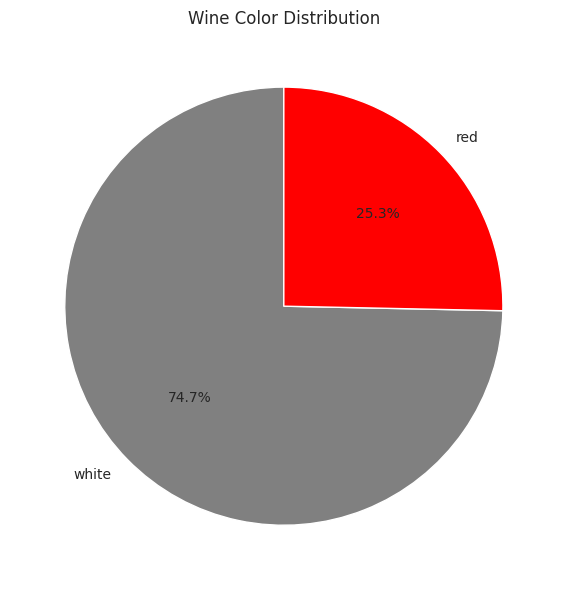

In [5]:
# exploratory visualization
#| fig-cap: "Distribution of Color for Wine in Training Dataset."
sns.set_style("white")
plt.figure(figsize=(6, 6))
colors = sns.color_palette("pastel", 4)
plt.pie(
    wine_train['color'].value_counts(),
    labels=wine_train['color'].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=['gray', 'red'],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Wine Color Distribution")
plt.tight_layout()
plt.show()

Here we can see that the color of the wine in the training dataset is predominantly white.

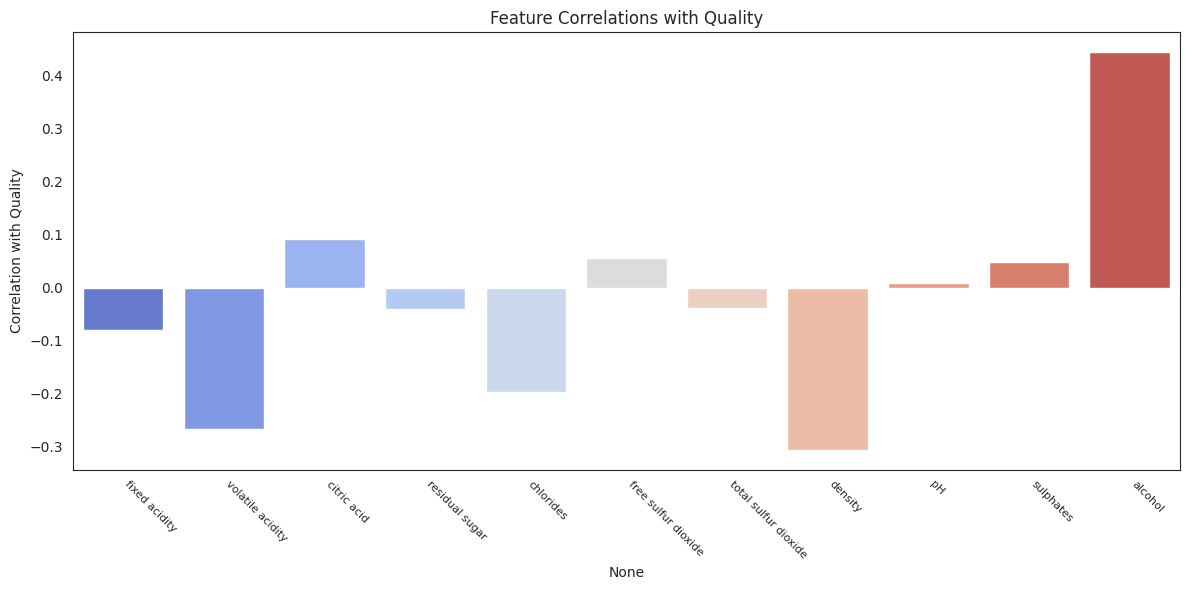

In [6]:
#| fig-cap: "Feature Relationships to Quality in Training Dataset"


quant = wine_train.columns.drop("color")
q = wine_train[quant].corr()['quality'].drop('quality')

plt.figure(figsize=(12,6))
sns.barplot(x=q.index, y=q.values, palette='coolwarm')
plt.xticks(rotation=-45, ha='left', fontsize=8)
plt.ylabel('Correlation with Quality')
plt.title('Feature Correlations with Quality')
plt.tight_layout()
plt.show()

This shows the correlation between the quantitative variables in the training dataset and wine quality. This provides some preliminary insight into what data may be most useful for predicting the target variable 'quality'. We can see that alcohol content has the strongest correlation to quality.

### Models

In [7]:
# process data for ML
cols = X_train.columns

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_transformer, cols[:11].tolist()),
        ("categorical", categorical_transformer, ['color']), 
    ],
    remainder='drop'
)

pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('regressor', knn())
    ]
)

This creates a procedure to preprocess the independent variable (feature) data before we put it into the model. There is a different procedure depending on whether the data is categorical (color) or numerical (alcohol content, pH, density etc.). These two procedures are combined to make an overall process for cleaning up the data. 

There are a few significant operations being performed on the data. The first one is filling in missing values (imputing). For numerical data, we are just plugging in the median value of the associated variable, but for categorical data, we are plugging in the most frequent. The second operation is scaling. Different variables have different standard deviations, so for numerical variables we scale it, so the mean is 0 and the standard deviation is 1. This ensures that a variable won't have an outsized impact on the model due to the nature of its variance. We also encode the categorical data, assigning 0s and 1s depending on the value, making it numerically processable.

Finally, we assign what process we want done to what columns, with 'color' (color of the wine) getting the categorical process and everything else getting the numerical process. We then combine this preprocessor with the type of regressor model we want to use (KNeighborsRegressor) to create an overall pipeline for our model.

In [8]:
# train models

params = {
    "regressor__n_neighbors": range(5, 20, 1),
    "regressor__p": [1, 2],
    "regressor__weights": ['uniform', 'distance']
}

mod = GridSearchCV(
    pipe,
    param_grid=params,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [9]:
mod.fit(X_train, y_train)

Next, we select a range of parameters we want to test on for our model. This includes how flexible we want the model to be, how we measure distance between datapoints, and how we weight those distances.

Then, we will try making a model with every possible combination of the metrics we give it, within the range we give it, and have it return the one with the best mean absolute error. The model is then fit with the training feature data (X_train) and the training target data (y_train).

## Results

In [10]:
# report model metrics
print(mod.best_params_)
print(mod.best_score_)

{'regressor__n_neighbors': 6, 'regressor__p': 1, 'regressor__weights': 'distance'}
-0.48086835925760163


The best model had a mean absolute error of 0.48. This means, on average, the quality that the model predicted was 0.48 points off of the real quality.

This model also used six neighbors, standard distance, and distance weights. 

In [11]:
test_accuracy = mod.score(X_test, y_test)
test_accuracy

-0.46258472193212025

On the test data, the model performed even better, with a mean absolute error of 0.46.

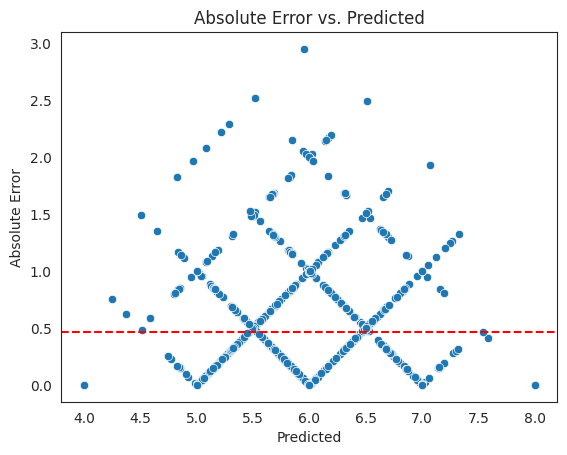

In [12]:
# summary figure
#| fig-cap: "Absolute Error vs. Predicted Value (Mean in Red Line)"

residuals = np.abs(y_test - mod.predict(X_test))
sns.scatterplot(x=mod.predict(X_test), y=residuals)
plt.xlabel('Predicted')
plt.ylabel('Absolute Error')
plt.title('Absolute Error vs. Predicted')
plt.axhline(-test_accuracy, linestyle='--', color='red')
plt.show()



The plot shows the absolute error of predictions across predicted quality scores. The red dashed line marks the average 0.5 error, meaning most predictions were within half a quality point of the real value, indicating the model generally predicts within an acceptable range. The X-shaped pattern is expected given the discrete nature of quality scores as errors naturally cluster at integer intervals.

In [13]:
# serialize model
dump(mod, 'wine.joblib')

['wine.joblib']

Finally, we will serialize the model by using the dump() function, making the model sharable.

## Discussion

The K-Nearest Neighbors regressor developed in this report demonstrates reasonable performance for predicting wine quality, achieving a mean absolute error of 0.46 on the test set. This means the model's predictions are on average less than half a quality point away from the true rating on a 0-10 scale, which is a meaningful level of accuracy for a subjective, human-assigned score.

This model would be suitable for deployment in a practical setting, such as assisting a winery or distributor in quality control. The primary benefit is that it replaces the need for a trained human sommelier to evaluate every bottle given only physiochemical measurements that can be collected with standard laboratory equipment, the model can produce a quality estimate quickly and at scale. This is particularly valuable in high-volume production environments where expert evaluation of every batch is not feasible.

However, several limitations should be considered before deploying this model. First, wine quality scores are inherently subjective and assigned by human tasters, meaning the model is ultimately learning to mimic human perception, which is variable. A model trained on one panel of tasters may not generalize to another. Second, the training data is heavily skewed toward white wine, which may cause the model to be less reliable for red wine predictions.

Finally, while a MAE of 0.46 is acceptable for general quality estimation, it may be insufficient in high-stakes contexts such as pricing premium wines, where a one-point misclassification could have significant financial consequences.